In [26]:
#Importing the required libraries
import pandas as pd
import numpy as np
import seaborn as sns
from matplotlib import pyplot as plt

In [27]:
# Load the dataset
df = pd.read_csv('../data/train.csv')

In [28]:
missing_data

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [29]:
# 2. Check for missing values (filtering to only show columns that actually have missing data)
print(missing_data[missing_data > 0].sort_values(ascending=False))

PoolQC          1453
MiscFeature     1406
Alley           1369
Fence           1179
MasVnrType       872
FireplaceQu      690
LotFrontage      259
GarageType        81
GarageYrBlt       81
GarageFinish      81
GarageQual        81
GarageCond        81
BsmtExposure      38
BsmtFinType2      38
BsmtQual          37
BsmtCond          37
BsmtFinType1      37
MasVnrArea         8
Electrical         1
dtype: int64


In [30]:
# 3. Get a quick count of Categorical vs Numerical data types
print("\nData Types Summary:")
print(df.dtypes.value_counts())


Data Types Summary:
object     43
int64      35
float64     3
Name: count, dtype: int64


In [31]:
df.head()


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [34]:
df.shape

(1460, 81)

**Data Cleaning (Handling NaNs)**

In [35]:
# --- 1. Drop Columns with Excessive Missing Data ---
# Dropping columns where more than 80% of the data is missing
columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']
df_cleaned = df.drop(columns=columns_to_drop)

# --- 2. Fill Remaining Missing Values ---
# Separate numerical and categorical columns
numeric_cols = df_cleaned.select_dtypes(include=['int64', 'float64']).columns
categorical_cols = df_cleaned.select_dtypes(include=['object']).columns

# Fill missing numerical values with the median
for col in numeric_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())

# Fill missing categorical values with the mode (most frequent value)
for col in categorical_cols:
    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

# --- 3. Verify Cleaning ---
total_missing = df_cleaned.isnull().sum().sum()
print(f"Total missing values after cleaning: {total_missing}")
print(f"Cleaned Dataset Shape: {df_cleaned.shape}")

Total missing values after cleaning: 0
Cleaned Dataset Shape: (1460, 75)


**Categorical Encoding**

In [36]:
# --- Categorical Encoding (One-Hot Encoding) ---
# Convert text categories into numerical data
# drop_first=True prevents redundant information (the dummy variable trap)
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

# Verify the transformation
print(f"Original Cleaned Shape: {df_cleaned.shape}")
print(f"New Encoded Shape: {df_encoded.shape}")

Original Cleaned Shape: (1460, 75)
New Encoded Shape: (1460, 231)


**Exploratory Data Analysis (EDA)**

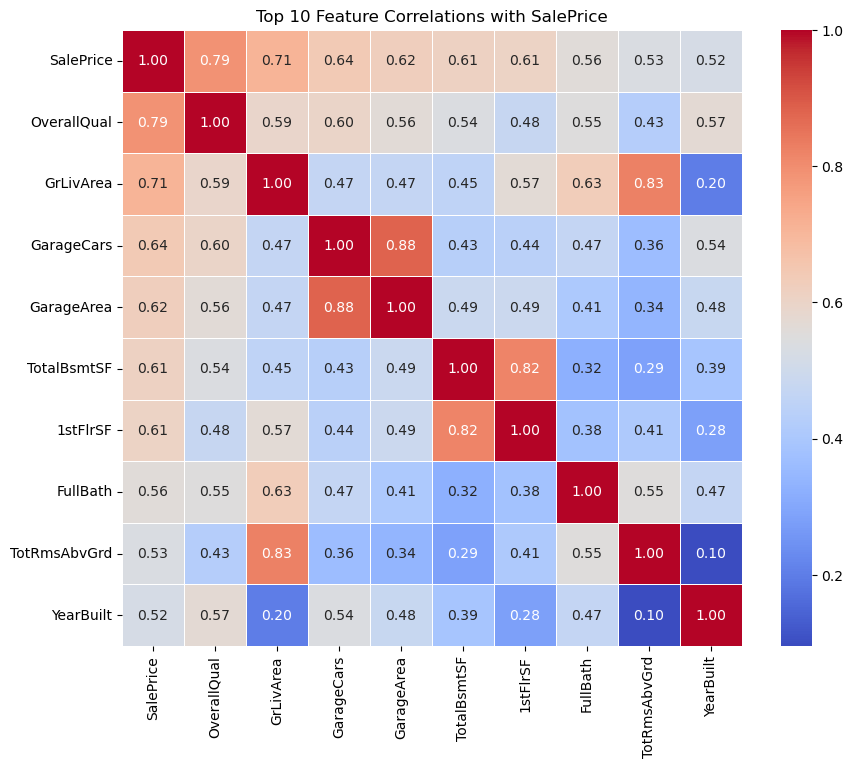

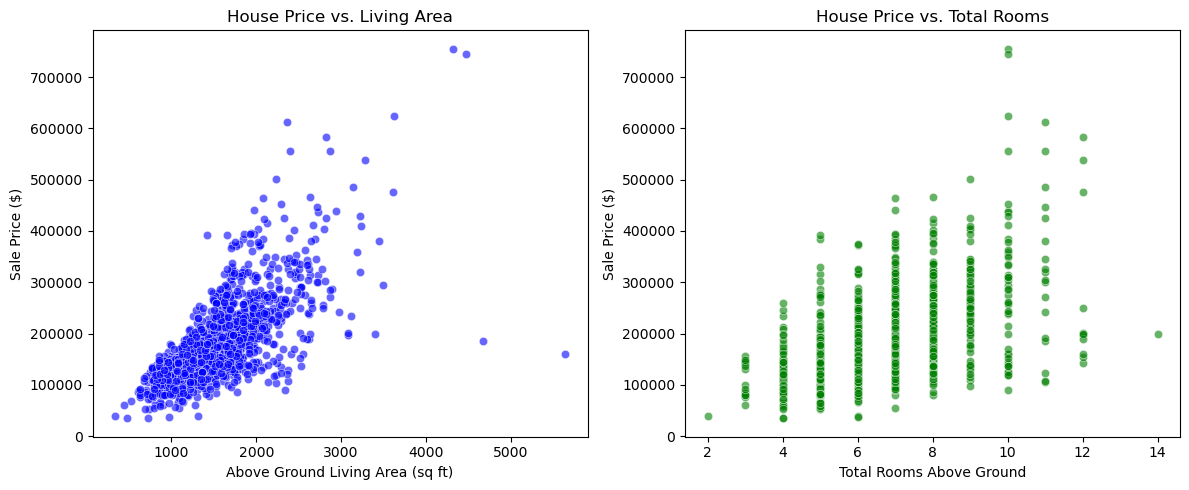

In [37]:
# --- 1. Correlation Heatmap ---
# Filter numerical features from the cleaned dataset
numeric_cols = df_cleaned.select_dtypes(include=['int64', 'float64'])
correlation_matrix = numeric_cols.corr()

# Extract top 10 features strongly correlated with SalePrice
top_corr_features = correlation_matrix['SalePrice'].sort_values(ascending=False).head(10).index

# Render heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(df_cleaned[top_corr_features].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title("Top 10 Feature Correlations with SalePrice")
plt.show()

# --- 2. Scatter Plots ---
plt.figure(figsize=(12, 5))

# SalePrice vs GrLivArea
plt.subplot(1, 2, 1)
sns.scatterplot(x=df_cleaned['GrLivArea'], y=df_cleaned['SalePrice'], alpha=0.6, color='blue')
plt.title("House Price vs. Living Area")
plt.xlabel("Above Ground Living Area (sq ft)")
plt.ylabel("Sale Price ($)")

# SalePrice vs TotRmsAbvGrd
plt.subplot(1, 2, 2)
sns.scatterplot(x=df_cleaned['TotRmsAbvGrd'], y=df_cleaned['SalePrice'], alpha=0.6, color='green')
plt.title("House Price vs. Total Rooms")
plt.xlabel("Total Rooms Above Ground")
plt.ylabel("Sale Price ($)")

plt.tight_layout()
plt.show()

**Categorical Encoding & Train/Test Split**

In [39]:
from sklearn.model_selection import train_test_split
import pandas as pd

# --- 1. Categorical Encoding ---
# Convert text categories into numerical format
# drop_first=True prevents multicollinearity 
df_encoded = pd.get_dummies(df_cleaned, drop_first=True)

# --- 2. Separate Features (X) and Target (y) ---
# Isolate the target variable (SalePrice) from the feature set
X = df_encoded.drop('SalePrice', axis=1)
y = df_encoded['SalePrice']

# --- 3. Train/Test Split ---
# Allocate 80% of data for model training and 20% for testing validation
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# --- 4. Verify Split Dimensions ---
print(f"Total features after encoding: {X.shape[1]}")
print(f"Training set: {X_train.shape[0]} rows")
print(f"Testing set: {X_test.shape[0]} rows")

Total features after encoding: 230
Training set: 1168 rows
Testing set: 292 rows


**Baseline Model (Linear Regression)**

In [40]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# --- 1. Initialize and Train the Model ---
# Instantiate the algorithm
lr_model = LinearRegression()

# Train (fit) the model using the 1168 training rows
lr_model.fit(X_train, y_train)

# --- 2. Make Predictions ---
# Predict house prices using the 292 unseen testing rows
y_pred_lr = lr_model.predict(X_test)

# --- 3. Evaluate Performance ---
# Calculate how close the predicted prices are to the actual testing prices
mae = mean_absolute_error(y_test, y_pred_lr)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lr))
r2 = r2_score(y_test, y_pred_lr)

print("--- Linear Regression Performance ---")
print(f"Mean Absolute Error (MAE): ${mae:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse:,.2f}")
print(f"R-squared (R2) Score: {r2:.4f}")

--- Linear Regression Performance ---
Mean Absolute Error (MAE): $20,384.19
Root Mean Squared Error (RMSE): $51,992.05
R-squared (R2) Score: 0.6476


**Advanced Model (Random Forest) & Feature Importance**

In [41]:
from sklearn.ensemble import RandomForestRegressor

# --- 1. Initialize and Train Random Forest ---
# random_state=42 ensures reproducibility
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

# --- 2. Make Predictions ---
y_pred_rf = rf_model.predict(X_test)

# --- 3. Evaluate Performance ---
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print("--- Random Forest Performance ---")
print(f"Mean Absolute Error (MAE): ${mae_rf:,.2f}")
print(f"Root Mean Squared Error (RMSE): ${rmse_rf:,.2f}")
print(f"R-squared (R2) Score: {r2_rf:.4f}\n")

# --- 4. Feature Importance Interpretation ---
# Extract the most influential features according to the model
feature_importances = pd.Series(rf_model.feature_importances_, index=X.columns)
top_5_features = feature_importances.sort_values(ascending=False).head(5)

print("--- Top 5 Most Influential Features ---")
print(top_5_features)

--- Random Forest Performance ---
Mean Absolute Error (MAE): $17,658.60
Root Mean Squared Error (RMSE): $29,061.62
R-squared (R2) Score: 0.8899

--- Top 5 Most Influential Features ---
OverallQual    0.557312
GrLivArea      0.120895
2ndFlrSF       0.034139
TotalBsmtSF    0.034134
BsmtFinSF1     0.029357
dtype: float64


**Prepping the Kaggle Test Data**

In [42]:
# --- 1. Load the Kaggle Test Data ---
# Note: make sure the filename matches exactly what you downloaded
test_df = pd.read_csv('../data/test.csv')

# Save the 'Id' column for the final Kaggle submission file
test_ids = test_df['Id']

# --- 2. Apply the Same Cleaning Steps ---
# Drop the same exact columns
columns_to_drop = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']
test_cleaned = test_df.drop(columns=columns_to_drop)

# Fill missing values
num_cols = test_cleaned.select_dtypes(include=['int64', 'float64']).columns
cat_cols = test_cleaned.select_dtypes(include=['object']).columns

for col in num_cols:
    test_cleaned[col] = test_cleaned[col].fillna(test_cleaned[col].median())

for col in cat_cols:
    test_cleaned[col] = test_cleaned[col].fillna(test_cleaned[col].mode()[0])

# --- 3. Categorical Encoding & Alignment ---
test_encoded = pd.get_dummies(test_cleaned, drop_first=True)

# THE FIX: Align the test columns to match the training columns exactly
# Any missing columns get filled with 0s
test_encoded = test_encoded.reindex(columns=X.columns, fill_value=0)

# --- 4. Verify Final Shape ---
print(f"Kaggle Test Features Shape: {test_encoded.shape}")

Kaggle Test Features Shape: (1459, 230)


**Final Predictions**

In [43]:
# --- 1. Make Final Predictions ---
# Predict house prices for the test data using the trained Random Forest model
final_predictions = rf_model.predict(test_encoded)

# --- 2. Format for Kaggle ---
# Create a final dataframe containing only the 'Id' and the predicted 'SalePrice'
submission_df = pd.DataFrame({
    'Id': test_ids,
    'SalePrice': final_predictions
})

# --- 3. Save to CSV ---
# Export the dataframe to a CSV file (index=False prevents writing pandas row numbers)
submission_df.to_csv('outputs/rf_predictions.csv', index=False)

print("Kaggle submission file saved successfully!")
print("\nFirst 5 predictions:")
print(submission_df.head())

Kaggle submission file saved successfully!

First 5 predictions:
     Id  SalePrice
0  1461  130066.83
1  1462  153717.50
2  1463  178996.35
3  1464  187441.56
4  1465  202882.74
